Device:  cuda


Iteration 9: 100%|██████████| 100/100 [09:03<00:00,  5.43s/it, episode=1000, return=-768.449]


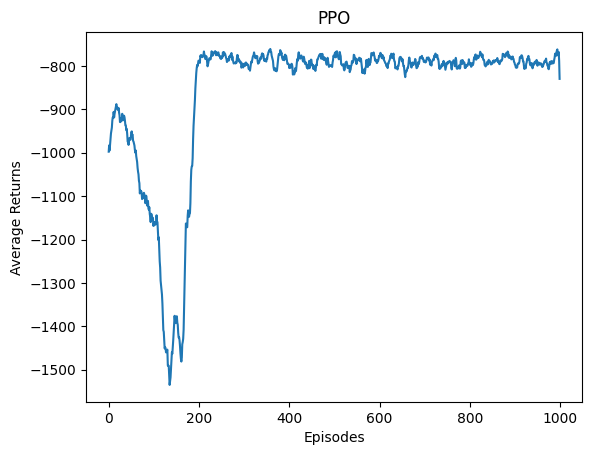

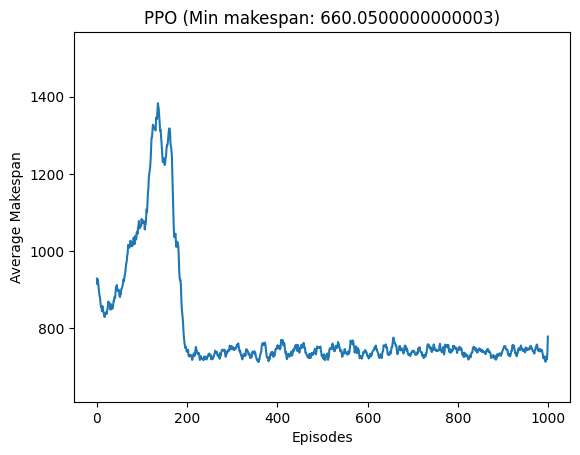

In [17]:
from HR_DRL import PPO
import numpy as np
import random
import torch
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
my_drl = PPO(hidden_dim=64, state_d=5*5*12, action_d=5*5,actor_lr=5e-4, critic_lr=1e-5)
instance_train = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(20)]
return_list, makespan_list, instance_makespan = my_drl.train_loop(instance_list=instance_train,episodes=1000)

In [31]:
from new_env import JSRS
from HR_DRL import STSP_prob
import torch.nn.functional as F
final_actor = my_drl.actor
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
instance_names = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(25)]
makespan_li = []
for instance in instance_names:
    env = JSRS.make(instance,'Data/val/'+instance+'.jsr')
    status = env.reset()
    while not status.done:
        state, avail, avail_bi, node = my_drl.get_state_vec(status)
        prob_STSP = STSP_prob(status).to(device)
        nonavail = [1 - i for i in avail]
        nonavail_bi = [1 - i for i in avail_bi]
        state_avail = torch.tensor(state * avail, dtype=torch.float).detach()
        state_nonavail = torch.tensor(state * nonavail, dtype=torch.float).detach()
        # avail and nonavail mask
        prob_avail = final_actor(state_avail.to(device)).view(-1, 1)
        prob_nonavail = final_actor(state_nonavail.to(device)).view(-1, 1)
        avail_bi = torch.tensor(avail_bi, dtype=torch.float).to(device).view(-1, 1)
        nonavail_bi = torch.tensor(nonavail_bi, dtype=torch.float).to(device).view(-1, 1)
        prob_avail_norm = F.normalize((prob_avail*avail_bi).clone().detach(), p=1, dim=0)
        prob_non = (prob_nonavail*(nonavail_bi)).mean(dim=0)
        # STSP based DRL
        prob = prob_avail_norm+prob_non*(nonavail_bi)+prob_STSP+1e-6

        action_prob = F.normalize(prob, p=1, dim=0)
        action_dist = torch.distributions.Categorical(action_prob.squeeze())
        action_num = action_dist.sample().item()
        action_node = node[action_num]
        action = [item for item in status.available_operations if item is not None and item[0] == action_node[0] and item[1] == action_node[1]]
        action = action[0] if len(action) == 1 else None
        next_status = env.step(action)
        status = next_status
    makespan_li.append(env.makespan)
print(makespan_li)
print(np.mean(makespan_li))

[459.5, 585.3, 562.4, 201.0, 313.3, 516.9, 330.7, 1140.8, 697.3, 321.8, 922.6, 731.7, 543.4, 746.8, 871.5, 694.6, 762.3, 984.0, 1158.4, 776.2, 2868.9, 3565.4, 2683.1, 2438.6, 3406.3]
1131.312


In [32]:
ins_1 = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(25)]

# import rules
from PDR import Random,SPT,FIFO,MOR,MWKR
import pandas as pd
r1 = Random(in_list=ins_1,data_file='Data/val/')
s1=SPT(in_list=ins_1,data_file='Data/val/')
f1=FIFO(in_list=ins_1,data_file='Data/val/')
m1=MOR(in_list=ins_1,data_file='Data/val/')
MW1=MWKR(in_list=ins_1,data_file='Data/val/')

p3_result = pd.DataFrame({
    'random':r1,
    'SPT': s1,
    'FIFO': f1,
    'MOR': m1,
    'MWKR': MW1,
})
p3_result['DRL'] = makespan_li
print(p3_result)
print(p3_result.mean(axis=0))

    random     SPT    FIFO     MOR    MWKR     DRL
0    425.7   383.8   310.5   310.5   305.7   459.5
1    531.4   587.4   446.0   446.0   526.0   585.3
2    534.8   713.0   666.0   666.0   561.1   562.4
3    484.2   222.8   199.6   199.6   365.0   201.0
4    281.5   382.5   303.7   303.7   340.5   313.3
5    411.8   333.5   372.5   372.5   300.6   516.9
6    565.2   357.1   436.7   436.7   436.7   330.7
7   1554.4  1031.6  1055.8  1055.8  1033.8  1140.8
8    930.3   634.1   590.3   590.3   569.0   697.3
9    538.3   354.4   281.8   281.8   298.1   321.8
10   938.7   840.0   632.0   632.0   614.1   922.6
11   818.9  1609.2   918.3   918.3   940.7   731.7
12   809.9   533.5   552.4   552.4   564.9   543.4
13   770.0   743.0   791.8   791.8   803.5   746.8
14  1253.8  1350.4   850.6   850.6   836.6   871.5
15  1095.8   669.7   577.0   577.0   553.3   694.6
16  1065.8   794.5   846.4   846.4   852.0   762.3
17  1136.3   916.8  1012.5  1012.5  1012.5   984.0
18  2258.6  2183.1  1454.4  145

In [39]:
from PDR import Random,SPT,LPT,FIFO,MOR,MWKR,SWKR,SSO,LSO
import pandas as pd
r1 = Random(in_list=ins_1,data_file='Data/val/')
s1=SPT(in_list=ins_1,data_file='Data/val/')
l1=LPT(in_list=ins_1,data_file='Data/val/')
f1=FIFO(in_list=ins_1,data_file='Data/val/')
m1=MOR(in_list=ins_1,data_file='Data/val/')
MW1=MWKR(in_list=ins_1,data_file='Data/val/')
SW1=SWKR(in_list=ins_1,data_file='Data/val/')
SS1=SSO(in_list=ins_1,data_file='Data/val/')
LS1=LSO(in_list=ins_1,data_file='Data/val/')
p3_result = pd.DataFrame({
    'random':r1,
    'SPT': s1,
    'LPT':l1,
    'FIFO': f1,
    'MOR': m1,
    'MWKR': MW1,
    'SWKR':SW1,
    'SSO':SS1,
    'LSO':LS1
})
p3_result['DRL'] = makespan_li
print(p3_result)
print(p3_result.mean(axis=0))

TypeError: '<' not supported between instances of 'Stage' and 'Stage'

Device:  cuda


Iteration 9: 100%|██████████| 50/50 [04:41<00:00,  5.64s/it, episode=500, return=-802.181, makespan=753.521, min_makespan=657.490]


{'M1': [['J2', 0, 78.0], ['J4', 78.0, 112.2], ['J2', 112.2, 144.0], ['J5', 144.0, 160.2], ['J1', 160.2, 184.4]], 'M2': [['J1', 0, 88.2], ['J5', 160.2, 291.2]], 'M3': [['J4', 0, 40.0], ['J5', 88.2, 122.6]], 'M4': [['J4', 112.2, 130.2], ['J2', 144.0, 171.9], ['J1', 184.4, 217.7], ['J3', 345.4]], 'M5': [['J3', 0, 190.9], ['J3', 190.9, 345.4]]}


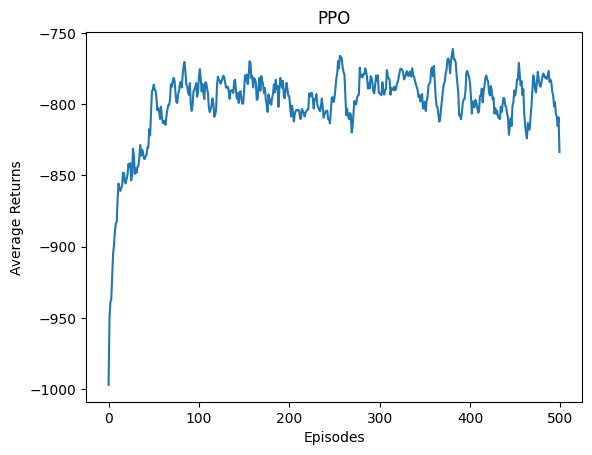

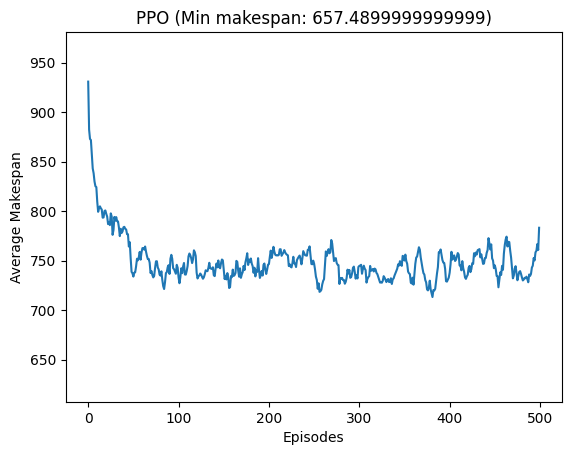

In [2]:
from HR_DRL_busy_balance import PPO
import numpy as np
import random
import torch
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
my_drl = PPO(hidden_dim=128, state_d=5*5*12, action_d=5*5,actor_lr=5e-4, critic_lr=1e-5)
instance_train = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(20)]
return_list, makespan_list, instance_makespan = my_drl.train_loop(instance_list=instance_train,episodes=500)

In [3]:
from new_env import JSRS
from HR_DRL_busy_balance import STSP_prob, busy_balance
import torch.nn.functional as F
final_actor = my_drl.actor
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
instance_names = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(25)]
makespan_li = []
for instance in instance_names:
    env = JSRS.make(instance,'Data/val/'+instance+'.jsr')
    status = env.reset()
    while not status.done:
        state, avail, avail_bi, node = my_drl.get_state_vec(status)
        prob_STSP = STSP_prob(status).to(device)
        prob_workload = busy_balance(status).to(device)
        nonavail = [1 - i for i in avail]
        nonavail_bi = [1 - i for i in avail_bi]
        state_avail = torch.tensor(state * avail, dtype=torch.float).detach()
        state_nonavail = torch.tensor(state * nonavail, dtype=torch.float).detach()
        # avail and nonavail mask
        prob_avail = final_actor(state_avail.to(device)).view(-1, 1)
        prob_nonavail = final_actor(state_nonavail.to(device)).view(-1, 1)
        avail_bi = torch.tensor(avail_bi, dtype=torch.float).to(device).view(-1, 1)
        nonavail_bi = torch.tensor(nonavail_bi, dtype=torch.float).to(device).view(-1, 1)
        prob_avail_norm = F.normalize((prob_avail*avail_bi).clone().detach(), p=1, dim=0)
        prob_non = (prob_nonavail*(nonavail_bi)).mean(dim=0)
        # KGDRL
        prob_guidance = prob_STSP+0.1*prob_workload
        prob = prob_avail_norm+prob_non*(nonavail_bi)+prob_guidance+1e-6

        action_prob = F.normalize(prob, p=1, dim=0)
        action_dist = torch.distributions.Categorical(action_prob.squeeze())
        action_num = action_dist.sample().item()
        action_node = node[action_num]
        action = [item for item in status.available_operations if item is not None and item[0] == action_node[0] and item[1] == action_node[1]]
        action = action[0] if len(action) == 1 else None
        next_status = env.step(action)
        status = next_status
    makespan_li.append(env.makespan)
print(makespan_li)
print(np.mean(makespan_li))

[335.2, 684.4, 506.2, 488.4, 317.8, 347.8, 350.4, 1228.5, 597.6, 343.1, 662.6, 947.5, 633.4, 798.4, 781.4, 806.3, 983.7, 1087.4, 1309.5, 772.2, 2868.8, 4142.4, 2594.9, 2517.2, 3463.4]
1182.74


In [1]:
#validation trantime,makespan csv
ins_1 = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(25)]

# import rules
from PDR import Random,FIFO,MWKR
import pandas as pd
r1 = Random(in_list=ins_1,data_file='Data/val/')
f1=FIFO(in_list=ins_1,data_file='Data/val/')
MW1=MWKR(in_list=ins_1,data_file='Data/val/')